<a href="https://colab.research.google.com/github/Charlesphilip6/Charlesgeospatial/blob/main/Data_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================
# 📊 Savanna Zones Analysis
# ============================

# Step 1: Setup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your CSV file (upload via Colab or mount Google Drive)
df = pd.read_csv("/content/for_data_analysis_table_1.csv")

# Quick preview
df.head()


,Years,SPEI,SPEI.1,SPEI.2,NDVI,NDVI.1,NDVI.2,VCI,VCI.1,VCI.2,VHI,VHI.1,VHI.2,TCI,TCI.1,TCI.2
0,NaN,Guinea,Sudan,Sahel,Guinea,Sudan,Sahel,Guinea,Sudan,Sahel,Guinea,Sudan,Sahel,Guinea,Sudan,Sahel
1,1994.0,-0.628,-0.829,-0.54,0.172,0.142,0.149,26.104,40.342,31.038,52.842,64.779,65.004,82.224,79.573,70.495
2,1995.0,-0.654,-1.396,-0.954,0.234,0.186,0.208,58.631,60.347,65.795,52.997,56.07,44.44,31.953,40.676,35.867
3,1996.0,-0.081,-0.974,-0.69,0.222,0.185,0.211,54.038,59.052,64.815,38.625,51.698,41.762,42.352,36.04,36.472
4,1997.0,-0.182,-0.151,-0.574,0.244,0.19,0.207,68.312,57.495,54.275,56.577,56.082,33.422,36.161,52.846,53.18


### Check for Null Values
Let's check if there are any null values in the `df_processed` DataFrame.

In [ ]:
print('Null values before dropping:')
print(df_processed.isnull().sum())

# Get the list of columns that are actual indicator-region values (excluding 'Year')
indicator_region_cols = [col for col in df_processed.columns if col != 'Year']

# Convert indicator columns to numeric, coercing errors to NaN
for col in indicator_region_cols:
    df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

print('\nNull values after converting to numeric and coercing errors:')
print(df_processed.isnull().sum())

Null values before dropping:
Year           0
SPEI_Guinea    0
SPEI_Sudan     0
SPEI_Sahel     0
NDVI_Guinea    0
NDVI_Sudan     0
NDVI_Sahel     0
VCI_Guinea     0
VCI_Sudan      0
VCI_Sahel      0
VHI_Guinea     0
VHI_Sudan      0
VHI_Sahel      0
TCI_Guinea     0
TCI_Sudan      0
TCI_Sahel      0
dtype: int64

Null values after converting to numeric and coercing errors:
Year           0
SPEI_Guinea    0
SPEI_Sudan     0
SPEI_Sahel     0
NDVI_Guinea    0
NDVI_Sudan     0
NDVI_Sahel     0
VCI_Guinea     0
VCI_Sudan      0
VCI_Sahel      0
VHI_Guinea     0
VHI_Sudan      0
VHI_Sahel      0
TCI_Guinea     0
TCI_Sudan      0
TCI_Sahel      0
dtype: int64


### Remove Rows with Null Values
Now I will remove any rows that contain null values in the indicator columns to ensure clean data for further analysis.

In [ ]:
initial_rows = df_processed.shape[0]
df_processed.dropna(subset=indicator_region_cols, inplace=True)
final_rows = df_processed.shape[0]

print(f"Rows before dropping nulls: {initial_rows}")
print(f"Rows after dropping nulls: {final_rows}")
print(f"Number of rows dropped: {initial_rows - final_rows}")

print('\nNull values after dropping rows:')
print(df_processed.isnull().sum())
display(df_processed.head())

Rows before dropping nulls: 29
Rows after dropping nulls: 29
Number of rows dropped: 0

Null values after dropping rows:
Year           0
SPEI_Guinea    0
SPEI_Sudan     0
SPEI_Sahel     0
NDVI_Guinea    0
NDVI_Sudan     0
NDVI_Sahel     0
VCI_Guinea     0
VCI_Sudan      0
VCI_Sahel      0
VHI_Guinea     0
VHI_Sudan      0
VHI_Sahel      0
TCI_Guinea     0
TCI_Sudan      0
TCI_Sahel      0
dtype: int64


,Year,SPEI_Guinea,SPEI_Sudan,SPEI_Sahel,NDVI_Guinea,NDVI_Sudan,NDVI_Sahel,VCI_Guinea,VCI_Sudan,VCI_Sahel,VHI_Guinea,VHI_Sudan,VHI_Sahel,TCI_Guinea,TCI_Sudan,TCI_Sahel
0,1994,-0.628,-0.829,-0.540,0.172,0.142,0.149,26.104,40.342,31.038,52.842,64.779,65.004,82.224,79.573,70.495
1,1995,-0.654,-1.396,-0.954,0.234,0.186,0.208,58.631,60.347,65.795,52.997,56.070,44.440,31.953,40.676,35.867
2,1996,-0.081,-0.974,-0.690,0.222,0.185,0.211,54.038,59.052,64.815,38.625,51.698,41.762,42.352,36.040,36.472
3,1997,-0.182,-0.151,-0.574,0.244,0.190,0.207,68.312,57.495,54.275,56.577,56.082,33.422,36.161,52.846,53.180
4,1998,-0.044,-0.368,-0.817,0.239,0.181,0.205,63.594,57.393,54.903,39.606,40.937,25.791,42.777,58.553,57.630


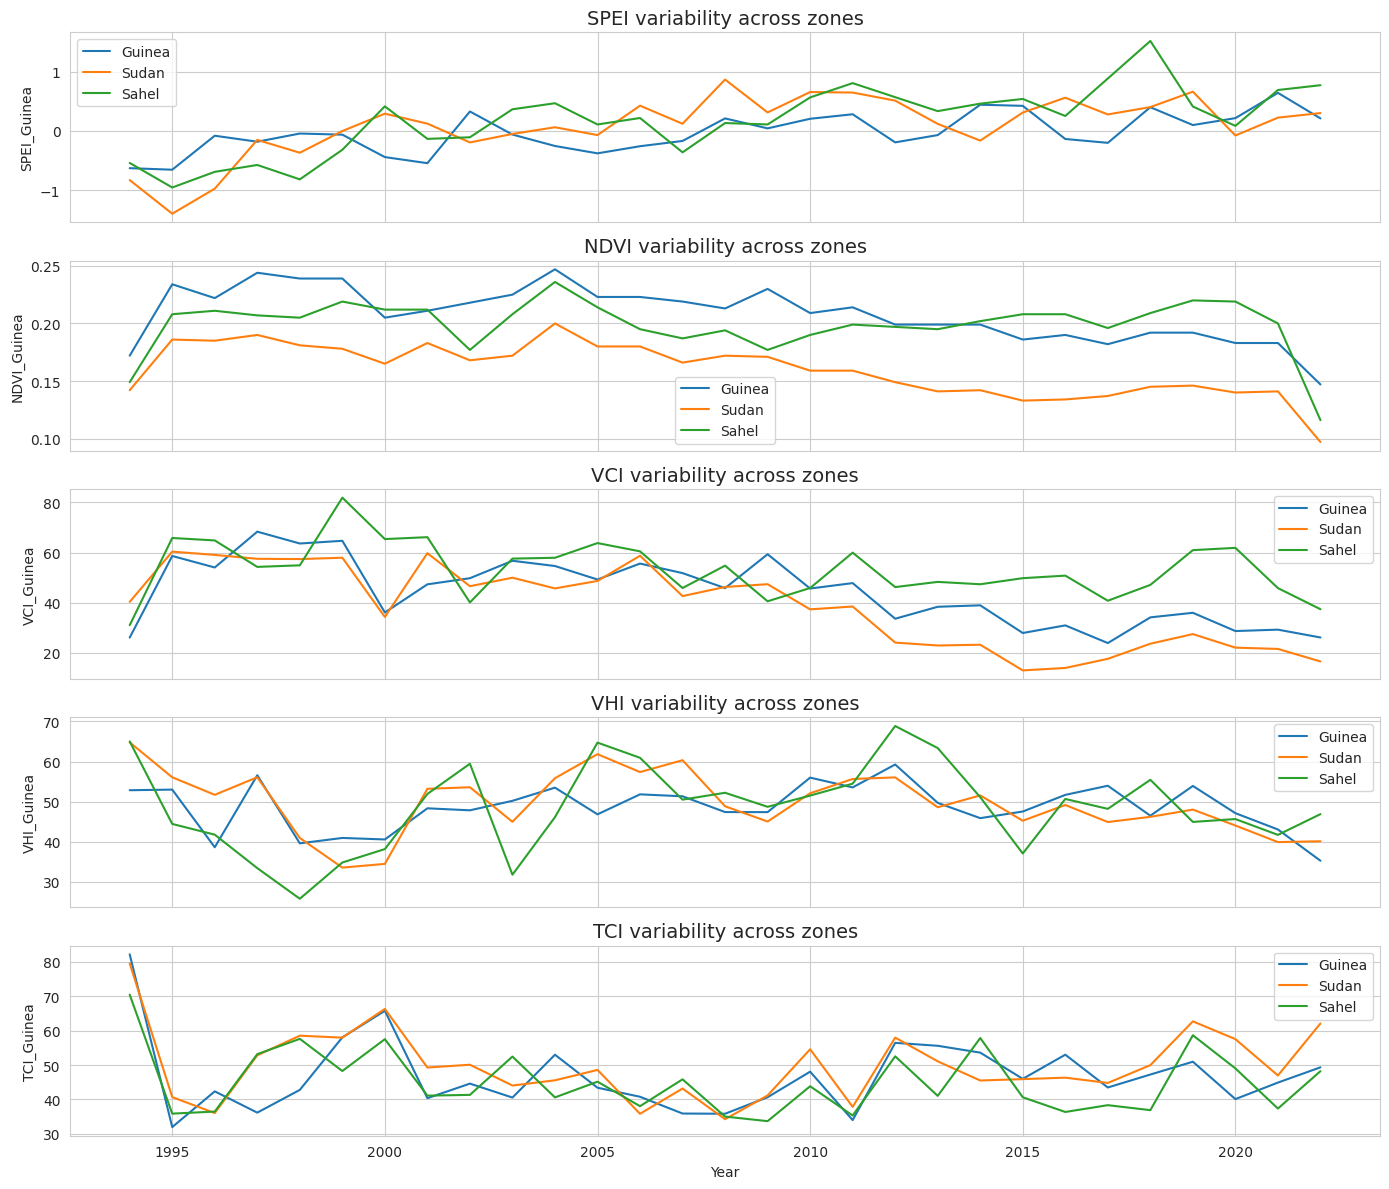

In [ ]:
# Define indicators and regions
indicators = ["SPEI", "NDVI", "VCI", "VHI", "TCI"]
regions = ["Guinea", "Sudan", "Sahel"]

sns.set_style("whitegrid")
fig, axes = plt.subplots(len(indicators), 1, figsize=(14, 12), sharex=True)

for i, ind in enumerate(indicators):
    for region in regions:
        col_to_plot = f"{ind}_{region}"
        if col_to_plot in df_processed.columns: # Ensure the column exists after renaming
            sns.lineplot(
                data=df_processed,
                x="Year",
                y=col_to_plot,
                label=region,
                ax=axes[i]
            )
        else:
            print(f"Warning: Column '{col_to_plot}' not found. Check data preprocessing.")
    axes[i].set_title(f"{ind} variability across zones", fontsize=14)
    axes[i].legend()

plt.tight_layout()
plt.show()

### Download Visualizations

The plots above illustrate the variability of different drought indicators across various zones. You can save this figure as an image file for external use or reporting.

In [ ]:
plot_filename = 'Indicator_Variability_Plots.png'
fig.savefig(plot_filename, dpi=300, bbox_inches='tight')

print(f"Plots saved to '{plot_filename}' in your Colab environment.")

# To make it downloadable in Colab:
from google.colab import files
files.download(plot_filename)

Plots saved to 'Indicator_Variability_Plots.png' in your Colab environment.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Download Final Processed Data
I'll now save the `df_processed` DataFrame, which contains the cleaned and restructured data, into a CSV file. This file will be named 'Spatio-Temporal Variability of Multi-source Drought Indicators across Savannah Zone.csv' and will be available for download.

In [ ]:
output_filename = 'Spatio-Temporal Variability of Multi-source Drought Indicators across Savannah Zone.csv'
df_processed.to_csv(output_filename, index=False)

print(f"DataFrame saved to '{output_filename}' in your Colab environment.")

# To make it downloadable in Colab:
from google.colab import files
files.download(output_filename)

DataFrame saved to 'Spatio-Temporal Variability of Multi-source Drought Indicators across Savannah Zone.csv' in your Colab environment.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================
# 📊 Savanna Zones Analysis
# ============================

# Step 1: Setup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your CSV file (upload via Colab or mount Google Drive)
df = pd.read_csv("/content/For data analysis (2).csv")

# Quick preview
df.head()


,Unnamed: 0,Rice,Unnamed: 2,Unnamed: 3,Maize,Unnamed: 5,Unnamed: 6,Sorghum,Unnamed: 8,Unnamed: 9,Millet,Unnamed: 11,Unnamed: 12
0,Year,Guinea,Sudan,Sahel,Guinea,Sudan,Sahel,Guinea,Sudan,Sahel,Guinea,Sudan,Sahel
1,1994,67.0,58.6,31.8,202.6,145.4,281.6,232.4,402.1,319.5,76.3,689.7,620.4
2,1995,246.3,43.1,31.2,165.1,132.6,267.1,212.1,363.5,305.4,93.4,364.0,617.6
3,1996,200.3,40.2,34.1,131.7,123.5,266.8,247.2,312.5,341.4,102.5,299.1,607.1
4,1997,189.0,38.9,41.0,216.4,98.7,192.1,191.2,289.9,289.0,84.4,290.7,425.7


### Data Preprocessing for Crop Yields

This section will clean and restructure the crop yield data. The current data has a multi-level header where the first row contains crop names and the second row contains region names. We will combine these to create single, descriptive column names (e.g., `Rice_Guinea`, `Maize_Sudan`). We will also ensure the 'Year' column is correctly formatted and all crop yield values are numeric.

In [ ]:
# Create a copy to work with
df_crops = df.copy()

# The actual column names are currently a mix:
# - Top level headers (df.columns) contain 'Unnamed: 0', 'Rice', 'Unnamed: 2', etc.
# - The first data row (df.iloc[0]) contains 'Year', 'Guinea', 'Sudan', 'Sahel', etc.

new_columns = []
current_crop_base = ''

# Handle the first column (Year)
first_col_level0 = str(df_crops.columns[0]).strip() # 'Unnamed: 0'
first_col_level1 = str(df_crops.iloc[0, 0]).strip() # 'Year'

if first_col_level0 == 'Unnamed: 0' and first_col_level1 == 'Year':
    new_columns.append('Year')
    # No current_crop_base for 'Year' column
else:
    # Fallback if the first column structure is unexpected, should not happen
    new_columns.append(first_col_level0 if first_col_level0 else first_col_level1)

# Iterate through the rest of the columns to create 'Crop_Region' names
for i in range(1, len(df_crops.columns)):
    # Get main crop header from df.columns (e.g., 'Rice', 'Unnamed: 2')
    main_crop_header = str(df_crops.columns[i]).strip()
    # Get region header from df.iloc[0] (e.g., 'Guinea', 'Sudan')
    region_header = str(df_crops.iloc[0, i]).strip()

    if 'Unnamed' not in main_crop_header and main_crop_header: # This is a new main crop (e.g., 'Rice', 'Maize')
        current_crop_base = main_crop_header
        new_columns.append(f"{current_crop_base}_{region_header}")
    else: # This is an 'Unnamed' column, so it belongs to the previous main crop
        new_columns.append(f"{current_crop_base}_{region_header}")

# Assign the newly constructed column names to the DataFrame
df_crops.columns = new_columns

# Drop the row that contained the region names (which is now at index 0 in df_crops)
df_crops = df_crops.drop(0).reset_index(drop=True)

# Convert the 'Year' column to integer
df_crops['Year'] = df_crops['Year'].astype(int)

# Get a list of crop yield columns (all columns except 'Year')
crop_yield_cols = [col for col in df_crops.columns if col != 'Year']

# Convert crop yield columns to numeric, coercing errors to NaN
for col in crop_yield_cols:
    df_crops[col] = pd.to_numeric(df_crops[col], errors='coerce')

print("Cleaned Crop Yield DataFrame Info:")
df_crops.info()

print("\nFirst 5 rows of the cleaned crop yield data:")
display(df_crops.head())

Cleaned Crop Yield DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Year            29 non-null     int64  
 1   Rice_Guinea     29 non-null     float64
 2   Rice_Sudan      29 non-null     float64
 3   Rice_Sahel      29 non-null     float64
 4   Maize_Guinea    29 non-null     float64
 5   Maize_Sudan     29 non-null     float64
 6   Maize_Sahel     29 non-null     float64
 7   Sorghum_Guinea  29 non-null     float64
 8   Sorghum_Sudan   29 non-null     float64
 9   Sorghum_Sahel   29 non-null     float64
 10  Millet_Guinea   29 non-null     float64
 11  Millet_Sudan    29 non-null     float64
 12  Millet_Sahel    29 non-null     float64
dtypes: float64(12), int64(1)
memory usage: 3.1 KB

First 5 rows of the cleaned crop yield data:


,Year,Rice_Guinea,Rice_Sudan,Rice_Sahel,Maize_Guinea,Maize_Sudan,Maize_Sahel,Sorghum_Guinea,Sorghum_Sudan,Sorghum_Sahel,Millet_Guinea,Millet_Sudan,Millet_Sahel
0,1994,67.0,58.6,31.8,202.6,145.4,281.6,232.4,402.1,319.5,76.3,689.7,620.4
1,1995,246.3,43.1,31.2,165.1,132.6,267.1,212.1,363.5,305.4,93.4,364.0,617.6
2,1996,200.3,40.2,34.1,131.7,123.5,266.8,247.2,312.5,341.4,102.5,299.1,607.1
3,1997,189.0,38.9,41.0,216.4,98.7,192.1,191.2,289.9,289.0,84.4,290.7,425.7
4,1998,189.2,70.8,40.5,280.3,118.0,197.9,190.4,389.1,282.5,101.1,319.4,538.2


### Visualize Crop Yield Trends

Now that the crop yield data (`df_crops`) is clean and properly structured, let's visualize the yield trends over time for each crop across the different regions (Guinea, Sudan, Sahel). This will help in understanding how crop production has changed in these areas.

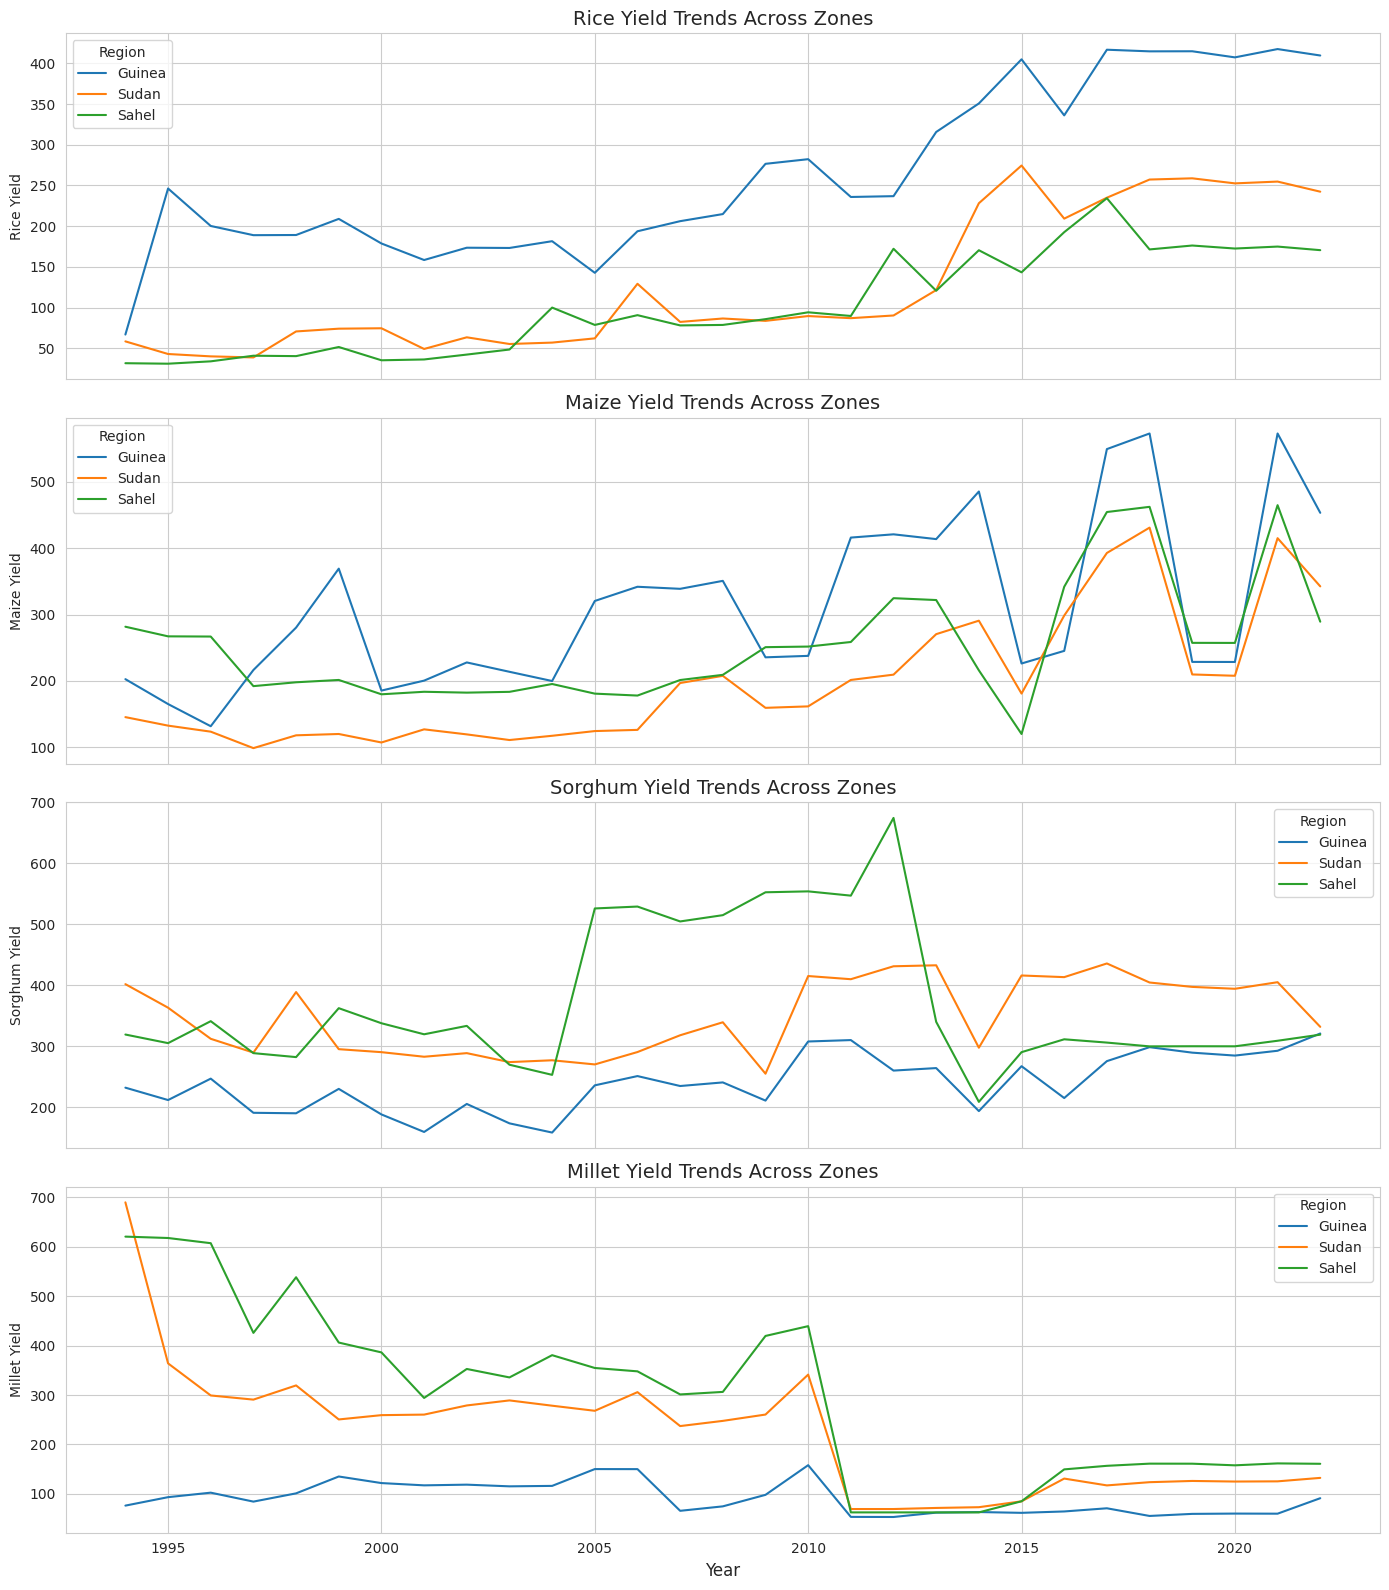

In [ ]:
# Define crops and regions for plotting
crops = ["Rice", "Maize", "Sorghum", "Millet"]
regions = ["Guinea", "Sudan", "Sahel"]

sns.set_style("whitegrid")
fig_crops, axes_crops = plt.subplots(len(crops), 1, figsize=(14, len(crops) * 4), sharex=True)

# Ensure axes_crops is always an array, even for a single subplot
if len(crops) == 1:
    axes_crops = [axes_crops]

for i, crop_name in enumerate(crops):
    for region in regions:
        col_to_plot = f"{crop_name}_{region}"
        if col_to_plot in df_crops.columns: # Ensure the column exists
            sns.lineplot(
                data=df_crops,
                x="Year",
                y=col_to_plot,
                label=region,
                ax=axes_crops[i]
            )
        else:
            print(f"Warning: Column '{col_to_plot}' not found. Check data preprocessing.")

    axes_crops[i].set_title(f"{crop_name} Yield Trends Across Zones", fontsize=14)
    axes_crops[i].set_ylabel(f"{crop_name} Yield")
    axes_crops[i].legend(title='Region')
    axes_crops[i].grid(True)

plt.xlabel("Year", fontsize=12)
plt.tight_layout()
plt.show()

### Interactive Plotly Visualizations

To allow for more interactive exploration, we can use Plotly to create zoomable and hoverable plots for both drought indicators and crop yields. This will provide a richer way to inspect the data over time.

In [ ]:
import plotly.express as px

# Plotly for Drought Indicators
for ind in indicators:
    fig_ind_plotly = px.line(
        df_processed,
        x="Year",
        y=[f"{ind}_{region}" for region in regions if f"{ind}_{region}" in df_processed.columns],
        title=f'{ind} Variability Across Zones (Interactive)',
        labels={'value': ind, 'variable': 'Region'}
    )
    fig_ind_plotly.show()

# Plotly for Crop Yields
for crop_name in crops:
    fig_crop_plotly = px.line(
        df_crops,
        x="Year",
        y=[f"{crop_name}_{region}" for region in regions if f"{crop_name}_{region}" in df_crops.columns],
        title=f'{crop_name} Yield Trends Across Zones (Interactive)',
        labels={'value': f'{crop_name} Yield', 'variable': 'Region'}
    )
    fig_crop_plotly.show()

### Rolling Averages for Smoothed Data

To smooth out short-term fluctuations and highlight longer-term trends in the data, we will compute rolling averages for both the drought indicators and crop yields. This can help in identifying more stable patterns.

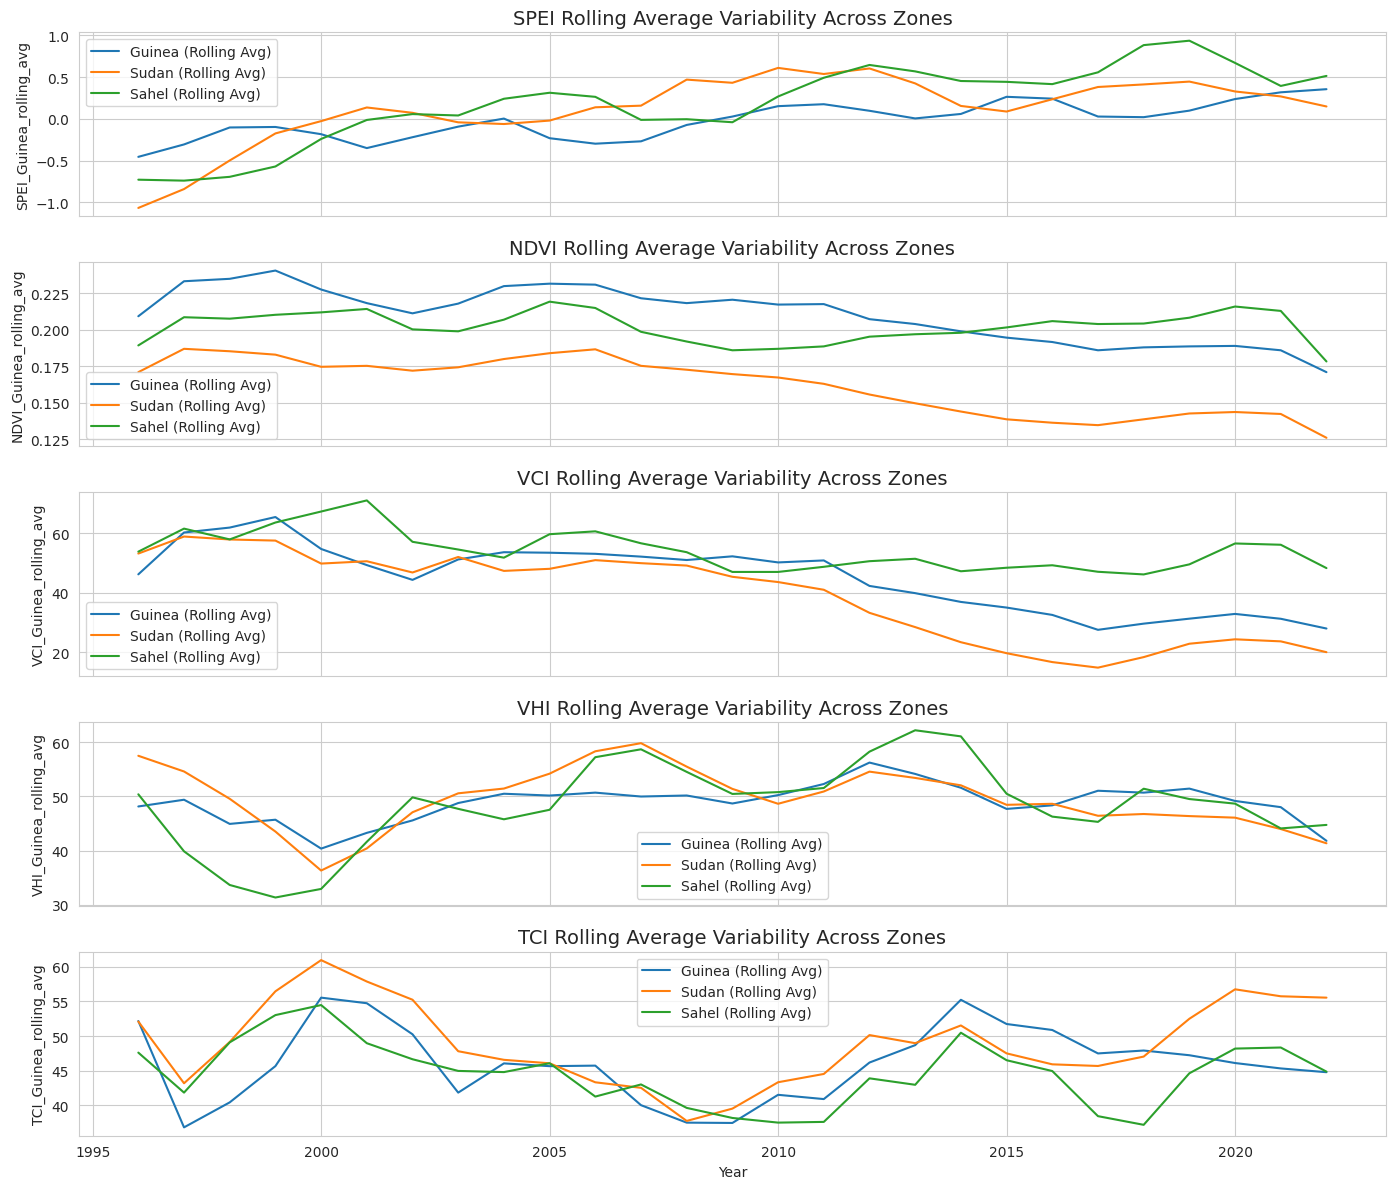

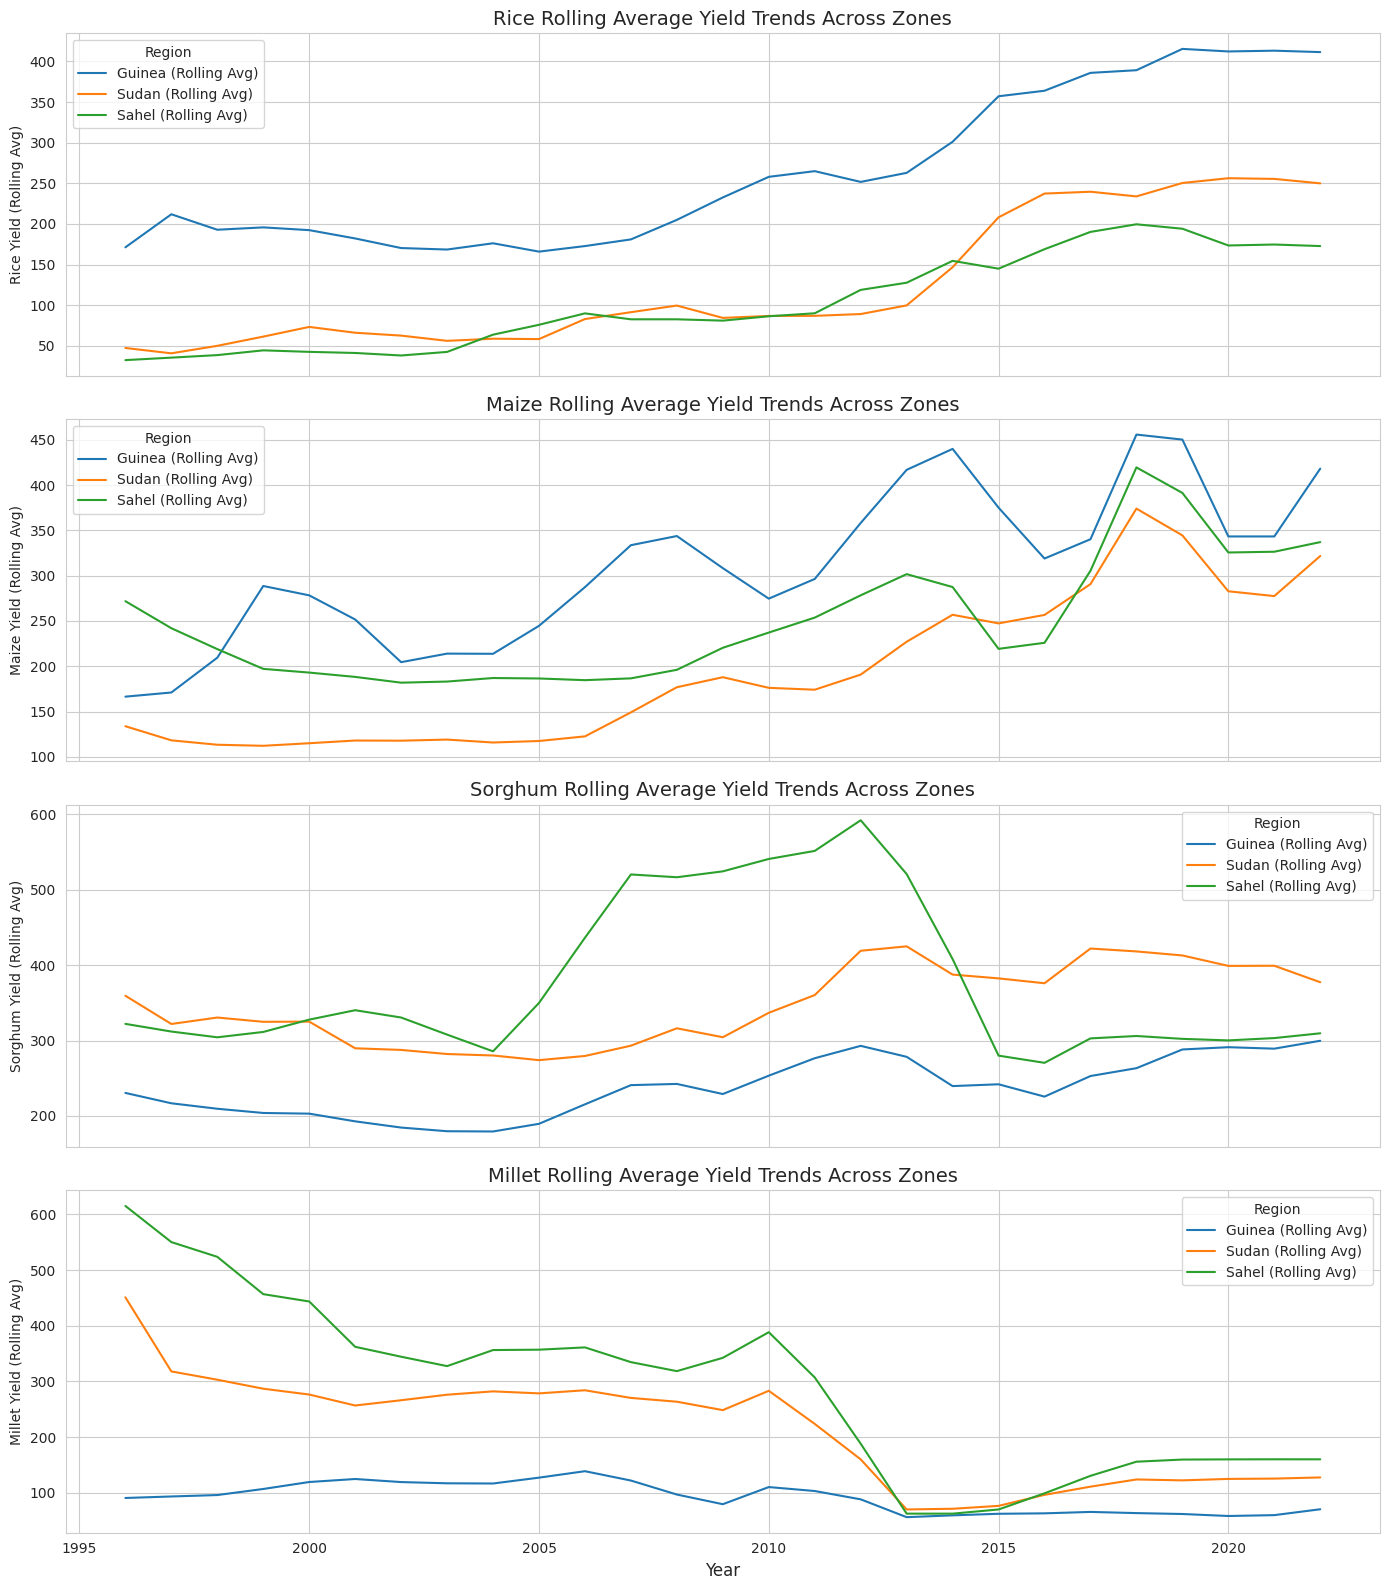

In [ ]:
# Define a window size for the rolling average (e.g., 3 years)
window_size = 3

# Calculate rolling averages for drought indicators
df_processed_rolling = df_processed.copy()
for col in indicator_region_cols:
    df_processed_rolling[f'{col}_rolling_avg'] = df_processed_rolling[col].rolling(window=window_size).mean()

# Calculate rolling averages for crop yields
df_crops_rolling = df_crops.copy()
for col in crop_yield_cols:
    df_crops_rolling[f'{col}_rolling_avg'] = df_crops_rolling[col].rolling(window=window_size).mean()

# Plotting Rolling Averages for Drought Indicators
fig_ind_rolling, axes_ind_rolling = plt.subplots(len(indicators), 1, figsize=(14, 12), sharex=True)

for i, ind in enumerate(indicators):
    for region in regions:
        col_to_plot_avg = f"{ind}_{region}_rolling_avg"
        if col_to_plot_avg in df_processed_rolling.columns:
            sns.lineplot(
                data=df_processed_rolling,
                x="Year",
                y=col_to_plot_avg,
                label=f'{region} (Rolling Avg)',
                ax=axes_ind_rolling[i]
            )
    axes_ind_rolling[i].set_title(f'{ind} Rolling Average Variability Across Zones', fontsize=14)
    axes_ind_rolling[i].legend()

plt.tight_layout()
plt.show()

# Plotting Rolling Averages for Crop Yields
fig_crop_rolling, axes_crop_rolling = plt.subplots(len(crops), 1, figsize=(14, len(crops) * 4), sharex=True)

if len(crops) == 1:
    axes_crop_rolling = [axes_crop_rolling]

for i, crop_name in enumerate(crops):
    for region in regions:
        col_to_plot_avg = f"{crop_name}_{region}_rolling_avg"
        if col_to_plot_avg in df_crops_rolling.columns:
            sns.lineplot(
                data=df_crops_rolling,
                x="Year",
                y=col_to_plot_avg,
                label=f'{region} (Rolling Avg)',
                ax=axes_crop_rolling[i]
            )
    axes_crop_rolling[i].set_title(f'{crop_name} Rolling Average Yield Trends Across Zones', fontsize=14)
    axes_crop_rolling[i].set_ylabel(f'{crop_name} Yield (Rolling Avg)')
    axes_crop_rolling[i].legend(title='Region')
    axes_crop_rolling[i].grid(True)

plt.xlabel("Year", fontsize=12)
plt.tight_layout()
plt.show()

### Correlation Heatmaps Between Drought Indicators and Crop Yields

To investigate the relationships between drought conditions and crop production, we will compute and visualize the correlation matrix between the various drought indicators and crop yields. This can help identify which indicators are most strongly associated with changes in crop yields.

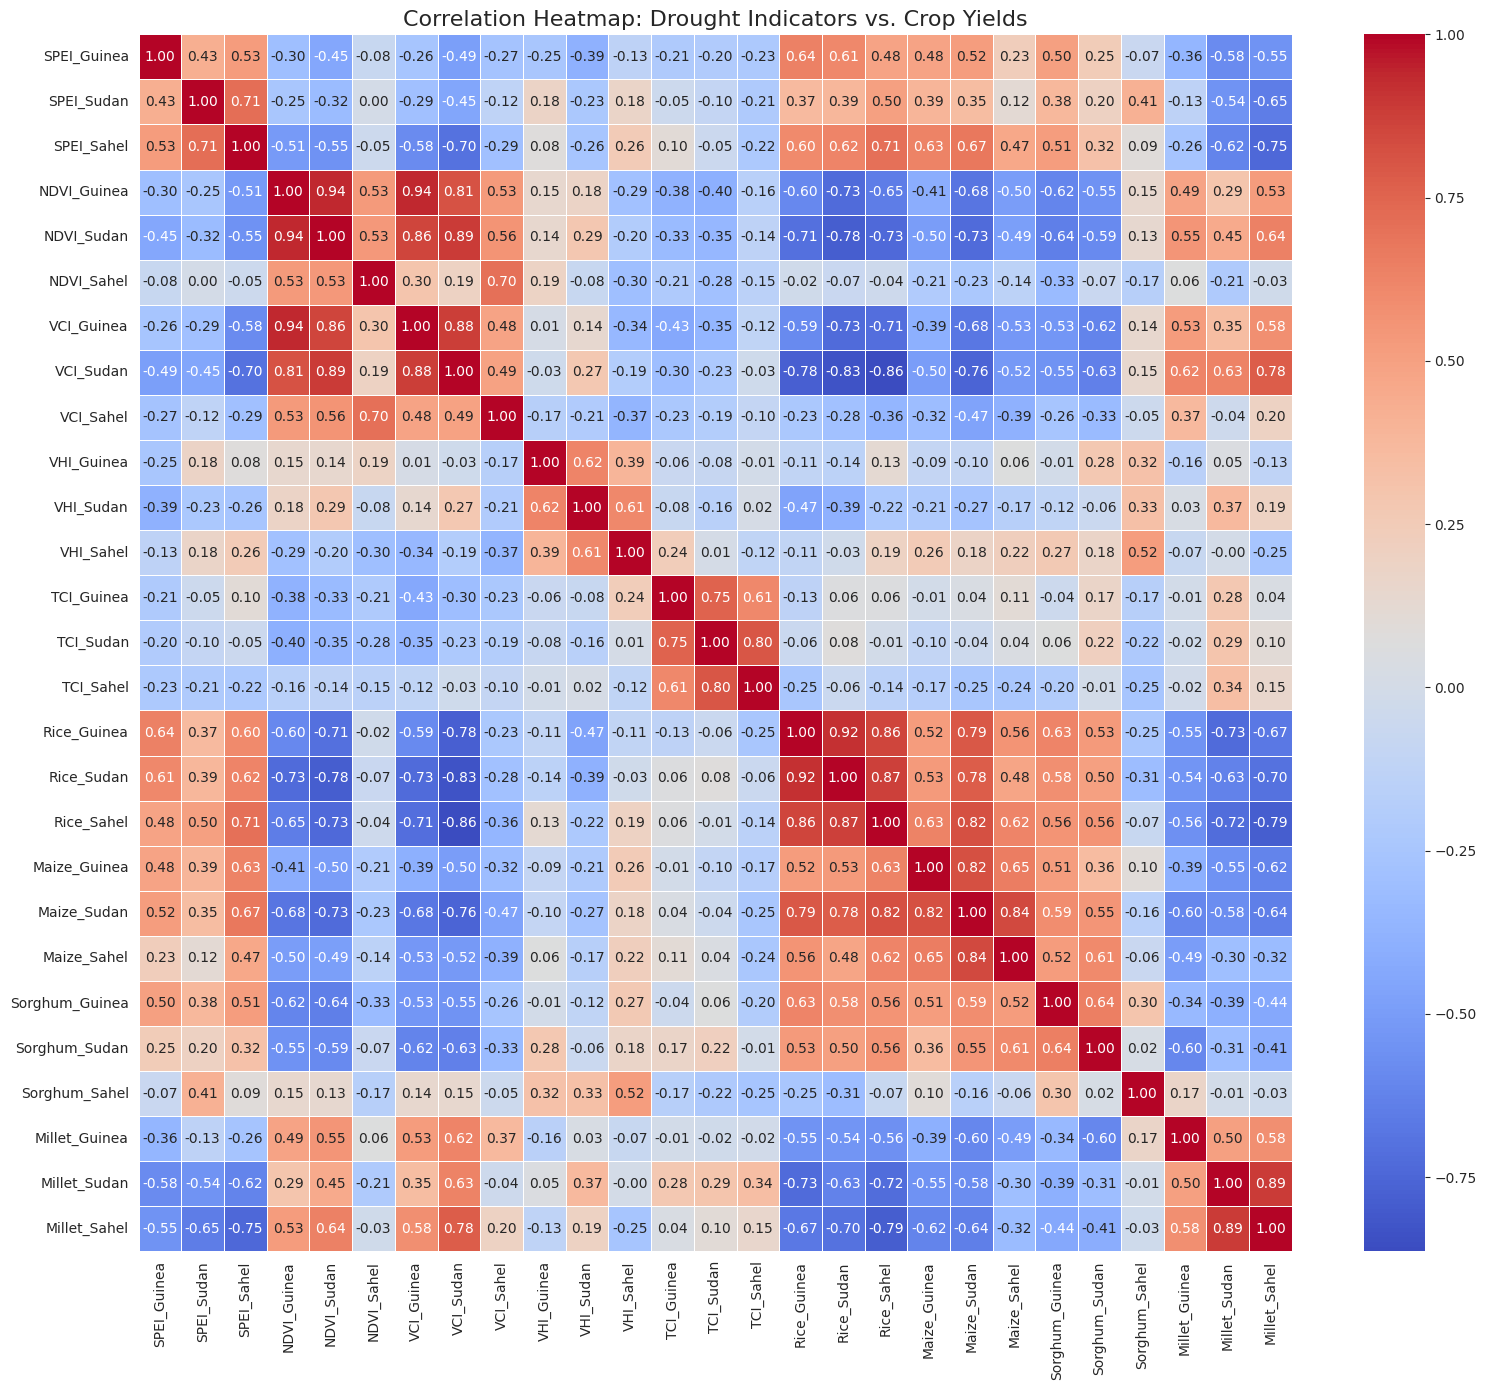

In [ ]:
# Merge the processed dataframes on 'Year'
df_merged = pd.merge(df_processed, df_crops, on='Year', how='inner')

# Select only the indicator and crop yield columns for correlation analysis
correlation_cols = indicator_region_cols + crop_yield_cols
df_correlation = df_merged[correlation_cols]

# Calculate the correlation matrix
correlation_matrix = df_correlation.corr()

# Plot the heatmap
fig_correlation_heatmap = plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap: Drought Indicators vs. Crop Yields', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Download Correlation Heatmap

You can download the generated correlation heatmap as an image file for use in your reports or presentations.

In [ ]:
correlation_heatmap_filename = 'Correlation_Heatmap_Drought_Indicators_vs_Crop_Yields.png'

# Use the explicitly stored figure object for saving
fig_correlation_heatmap.savefig(correlation_heatmap_filename, dpi=300, bbox_inches='tight')

print(f"Correlation heatmap saved to '{correlation_heatmap_filename}' in your Colab environment.")

from google.colab import files
files.download(correlation_heatmap_filename)

Correlation heatmap saved to 'Correlation_Heatmap_Drought_Indicators_vs_Crop_Yields.png' in your Colab environment.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Dual-Axis Plots: Overlaying Drought Indicators and Crop Yields

To gain deeper insights into how specific drought indicators might be influencing crop yields, we can create dual-axis plots. These plots will overlay a selected drought indicator and a corresponding crop yield for each region, allowing for direct visual comparison of their trends over time.

In [ ]:
import matplotlib.ticker as mticker
from google.colab import files

# Choose an indicator and a crop to compare (e.g., SPEI and Maize)
# You can iterate through other combinations as needed

selected_indicator = "SPEI"
selected_crop = "Maize"

for i, region in enumerate(regions):
    fig, ax1 = plt.subplots(figsize=(16, 6)) # Create a new figure for each region

    # Plot indicator on primary y-axis
    sns.lineplot(
        data=df_merged,
        x='Year',
        y=f'{selected_indicator}_{region}',
        label=f'{selected_indicator} ({region})',
        color='blue',
        ax=ax1
    )
    ax1.set_ylabel(f'{selected_indicator}', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.legend(loc='upper left')
    ax1.grid(True)

    # Plot crop yield on secondary y-axis
    ax2 = ax1.twinx()
    sns.lineplot(
        data=df_merged,
        x='Year',
        y=f'{selected_crop}_{region}',
        label=f'{selected_crop} Yield ({region})',
        color='red',
        linestyle='--',
        ax=ax2
    )
    ax2.set_ylabel(f'{selected_crop} Yield', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.legend(loc='upper right')

    ax1.set_title(f'{selected_indicator} vs. {selected_crop} Yield in {region}')
    ax1.set_xlabel('Year')

    plt.tight_layout()

    # Save the figure
    plot_filename = f'Dual_Axis_{selected_indicator}_{selected_crop}_{region}.png'
    fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
    print(f"Plot saved to '{plot_filename}' in your Colab environment.")

    # Make it downloadable
    files.download(plot_filename)

    plt.close(fig) # Close the figure to prevent it from being displayed inline again after saving

print("All dual-axis plots have been generated, saved, and made available for download.")

Plot saved to 'Dual_Axis_SPEI_Maize_Guinea.png' in your Colab environment.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Plot saved to 'Dual_Axis_SPEI_Maize_Sudan.png' in your Colab environment.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Plot saved to 'Dual_Axis_SPEI_Maize_Sahel.png' in your Colab environment.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All dual-axis plots have been generated, saved, and made available for download.


### Download Crop Yield Trend Visualizations

To make these crop yield trend plots easily accessible, you can download them as an image file. This image summarizes the trends for Rice, Maize, Sorghum, and Millet across the Guinea, Sudan, and Sahel regions.

In [ ]:
plot_filename_crops = 'Crop Yield Trend across Savannah Agro-Ecological Zone.png'
fig_crops.savefig(plot_filename_crops, dpi=300, bbox_inches='tight')

print(f"Crop yield plots saved to '{plot_filename_crops}' in your Colab environment.")

# To make it downloadable in Colab:
from google.colab import files
files.download(plot_filename_crops)

Crop yield plots saved to 'Crop Yield Trend across Savannah Agro-Ecological Zone.png' in your Colab environment.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>